# Developer Code Defect Prediction

## Data Preprocessing

This notebook prepares the JM1 software defect dataset for Machine Learning.

The preprocessing pipeline is designed to produce clean and reliable input data while preventing data leakage between training and testing sets.

### Objectives

- Load the JM1 dataset
- Clean invalid and duplicate records
- Convert data types
- Handle missing values
- Separate features and target
- Split the dataset into training and testing sets
- Analyze feature relationships using training data
- Select relevant features
- Scale numerical features for suitable Machine Learning algorithms
- Handle class imbalance using training data only
- Prepare a reproducible preprocessing pipeline

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from imblearn.over_sampling import SMOTE

## 1. Load Dataset

The JM1 software defect dataset is loaded from the project data directory.

The dataset contains software engineering metrics and a binary defect target.

In [6]:
df = pd.read_csv("../data/jm1.csv")

print("Original dataset shape:", df.shape)

df.head()

Original dataset shape: (10885, 22)


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1,1,1,1,1,True
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17,36,112,86,13,True
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17,135,329,271,5,True
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11,16,76,50,7,True


## 2. Remove Exact Duplicate Records

Exact duplicate observations are removed to reduce the possibility of the same observation appearing in both the training and testing sets.

This helps prevent overly optimistic Machine Learning evaluation.

In [7]:
original_rows = len(df)

df = df.drop_duplicates().reset_index(drop=True)

removed_rows = original_rows - len(df)

print("Original rows:", original_rows)
print("Duplicate rows removed:", removed_rows)
print("Rows after duplicate removal:", len(df))

Original rows: 10885
Duplicate rows removed: 1973
Rows after duplicate removal: 8912


## 3. Convert Numeric Features

Some software metrics are stored as strings even though they represent numerical values.

The following features are converted into numeric format:

- `uniq_Op`
- `uniq_Opnd`
- `total_Op`
- `total_Opnd`
- `branchCount`

Invalid values such as `?` are converted into missing values for subsequent treatment.

In [8]:
string_columns = [
    "uniq_Op",
    "uniq_Opnd",
    "total_Op",
    "total_Opnd",
    "branchCount"
]

for column in string_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print(df[string_columns].dtypes)

uniq_Op        float64
uniq_Opnd      float64
total_Op       float64
total_Opnd     float64
branchCount    float64
dtype: object


## 4. Handle Missing Values

Invalid values identified during numeric conversion are represented as missing values.

Median imputation is used for numerical software metrics because the dataset contains highly skewed features and extreme values.

In [9]:
for column in string_columns:
    df[column] = df[column].fillna(df[column].median())

print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


## 5. Prepare Target Variable

The `defects` variable indicates whether a software module contains a defect.

- `False` → 0
- `True` → 1

The target is converted into an integer representation for Machine Learning.

In [10]:
df["defects"] = df["defects"].astype(int)

print("Target data type:", df["defects"].dtype)

print("\nTarget distribution:")
print(df["defects"].value_counts())

Target data type: int64

Target distribution:
defects
0    6905
1    2007
Name: count, dtype: int64


## 6. Final Dataset Validation

The cleaned dataset is checked for missing values, duplicate records, and data types before separating features and target.

In [11]:
print("Dataset shape:", df.shape)

print("Total missing values:", df.isnull().sum().sum())

print("Duplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (8912, 22)
Total missing values: 0
Duplicate rows: 0

Data types:
loc                  float64
v(g)                 float64
ev(g)                float64
iv(g)                float64
n                    float64
v                    float64
l                    float64
d                    float64
i                    float64
e                    float64
b                    float64
t                    float64
lOCode                 int64
lOComment              int64
lOBlank                int64
locCodeAndComment      int64
uniq_Op              float64
uniq_Opnd            float64
total_Op             float64
total_Opnd           float64
branchCount          float64
defects                int64
dtype: object


## 7. Separate Features and Target

The software engineering metrics are assigned to `X`, while the defect label is assigned to `y`.

The target variable is not included among the input features.

In [12]:
X = df.drop("defects", axis=1)
y = df["defects"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (8912, 21)
Target shape: (8912,)

Feature columns:
['loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd', 'i', 'e', 'b', 't', 'lOCode', 'lOComment', 'lOBlank', 'locCodeAndComment', 'uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount']


## 8. Train-Test Split

The dataset is divided into training and testing sets.

A stratified split is used so that the proportion of defective and non-defective modules remains similar in both sets.

The test set is kept completely separate and is not used for feature selection, scaling, or class balancing.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training features: (7129, 21)
Testing features: (1783, 21)

Training target distribution:
defects
0    5524
1    1605
Name: count, dtype: int64

Testing target distribution:
defects
0    1381
1     402
Name: count, dtype: int64


## 9. Class Distribution After Train-Test Split

The class distribution is checked after splitting to verify that stratification preserved the proportion of defective and non-defective modules.

In [14]:
print("Training defective percentage:",
      round(y_train.mean() * 100, 2), "%")

print("Testing defective percentage:",
      round(y_test.mean() * 100, 2), "%")

Training defective percentage: 22.51 %
Testing defective percentage: 22.55 %


## 10. Feature Selection Using Mutual Information

Mutual information is used to estimate the dependency between each software metric and the defect target.

The analysis is performed using the training data only to prevent information leakage from the test set.

Features with higher mutual information values provide stronger evidence of dependency with the target.

In [15]:
mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_scores = pd.Series(
    mi_scores,
    index=X_train.columns
).sort_values(ascending=False)

print("Mutual Information Scores:")
print(mi_scores)

Mutual Information Scores:
lOCode               0.040544
loc                  0.036943
v                    0.035780
total_Op             0.035014
uniq_Opnd            0.033431
lOBlank              0.028635
i                    0.027886
total_Opnd           0.026993
n                    0.026379
t                    0.025796
e                    0.025047
b                    0.024376
branchCount          0.024124
l                    0.024065
d                    0.022510
uniq_Op              0.020849
v(g)                 0.020800
iv(g)                0.020318
ev(g)                0.019568
lOComment            0.015018
locCodeAndComment    0.004182
dtype: float64


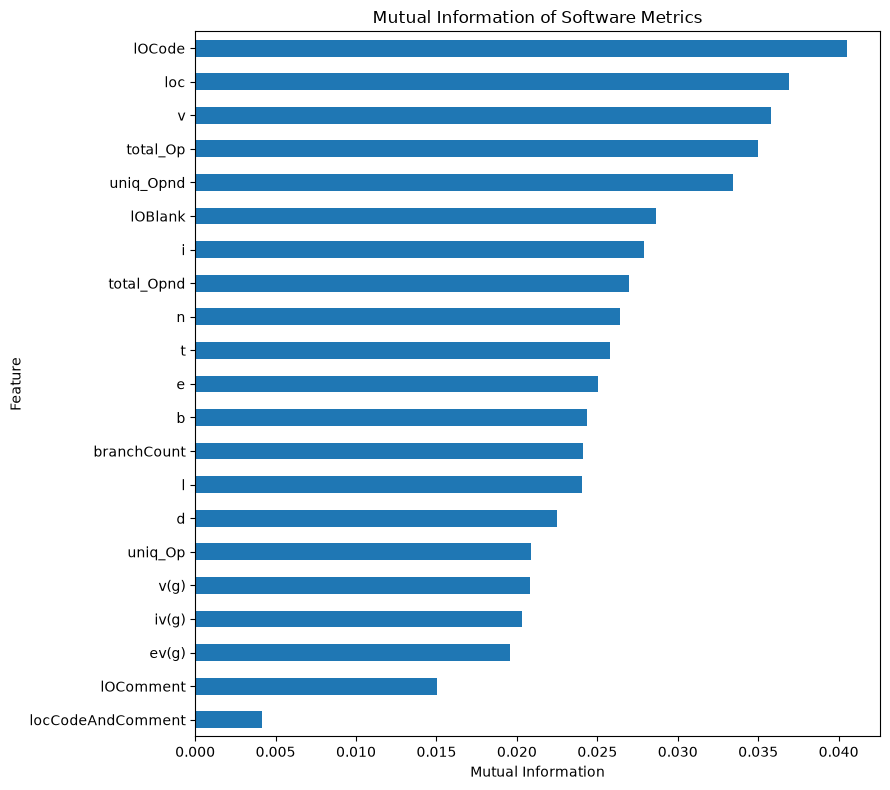

In [19]:
plt.figure(figsize=(9, 8))

mi_scores.sort_values().plot(kind="barh")

plt.title("Mutual Information of Software Metrics")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 11. Feature Selection Decision

The initial analysis shows relationships between multiple software metrics and the defect target.

Instead of removing features solely based on correlation or mutual information, all 21 features are retained for the initial Machine Learning experiments.

Model-based feature importance and validation performance will be used later to evaluate whether feature reduction improves the models.

In [20]:
selected_features = X_train.columns.tolist()

print("Number of selected features:", len(selected_features))
print("\nSelected features:")
print(selected_features)

Number of selected features: 21

Selected features:
['loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd', 'i', 'e', 'b', 't', 'lOCode', 'lOComment', 'lOBlank', 'locCodeAndComment', 'uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount']


## 12. Feature Scaling

Standardization is applied to the training features so that numerical variables have comparable scales.

The scaler is fitted only on the training data and then applied to the testing data.

This prevents information from the test set from influencing preprocessing.

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[selected_features])

X_test_scaled = scaler.transform(X_test[selected_features])

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (7129, 21)
Scaled testing shape: (1783, 21)


## 13. Handle Class Imbalance Using SMOTE

The dataset contains fewer defective modules than non-defective modules.

SMOTE is applied only to the training data to generate synthetic minority-class observations.

The testing data remains unchanged so that model evaluation reflects the original class distribution.

In [22]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Original training distribution:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Original training distribution:
defects
0    5524
1    1605
Name: count, dtype: int64

After SMOTE:
defects
1    5524
0    5524
Name: count, dtype: int64


## 14. Preprocessing Summary

The JM1 dataset has been prepared for Machine Learning.

### Preprocessing steps completed

- Removed exact duplicate records
- Converted numeric-looking string features
- Handled invalid values using median imputation
- Converted the target variable to binary integers
- Separated features and target
- Performed stratified train-test split
- Performed feature relevance analysis using mutual information
- Retained all 21 features for initial modeling
- Standardized features for scale-sensitive algorithms
- Applied SMOTE only to the training data

The test dataset remains untouched by SMOTE and is reserved for unbiased model evaluation.

In [23]:
print("Final preprocessing summary")
print("-" * 40)

print("Original cleaned features:", X.shape)
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Scaled training features:", X_train_scaled.shape)
print("Scaled testing features:", X_test_scaled.shape)

print("SMOTE training features:", X_train_smote.shape)
print("SMOTE training target:", y_train_smote.shape)

Final preprocessing summary
----------------------------------------
Original cleaned features: (8912, 21)
Training features: (7129, 21)
Testing features: (1783, 21)
Scaled training features: (7129, 21)
Scaled testing features: (1783, 21)
SMOTE training features: (11048, 21)
SMOTE training target: (11048,)


In [24]:
import os

os.makedirs("../data/processed", exist_ok=True)

X_train.to_csv("../data/processed/X_train.csv", index=False)
X_test.to_csv("../data/processed/X_test.csv", index=False)

y_train.to_csv("../data/processed/y_train.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.
